In [ ]:
!git clone https://github.com/Charith003/nu_data.git

Cloning into 'nu_data'...
remote: Enumerating objects: 8441, done.
remote: Total 8441 (delta 0), reused 0 (delta 0), pack-reused 8441 (from 1)
Receiving objects: 100% (8441/8441), 199.34 MiB | 40.46 MiB/s, done.
Resolving deltas: 100% (433/433), done.
Updating files: 100% (8427/8427), done.


In [ ]:
!ls nu_data

2009_ISBI_2DNuclei  BBBC020			stage_1_test
BBBC006		    cluster_nuclei		stage_1_train
BBBC007		    color_wikipedia		stage_2_test
BBBC018		    nuclei_partial_annotations	TNBC_NucleiSegmentation


In [ ]:
import os
import cv2
import time
import torch
import shap
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, precision_recall_curve, auc

In [ ]:
DATASET_PATH = "/content/nu_data"

TRAIN_FOLDER = os.path.join(DATASET_PATH, "stage_1_train")

print("Training folders:", os.listdir(TRAIN_FOLDER)[:5])

Training folders: ['2e172afb1f43b359f1f0208da9386aefe97c0c1afe202abfe6ec09cdca820990.jpg', 'a65bbfc5673e8053b6ce49f39c79cf3a846fe5cc46dd93105f74fb07cf44606d.jpg', '3a3fee427e6ef7dfd0d82681e2bcee2d054f80287aea7dfa3fa4447666f929b9.jpg', '0402a81e75262469925ea893b6706183832e85324f7b1e08e634129f5d522cdd.jpg', '55f98f43c152aa0dc8bea513f8ba558cc57494b81ae4ee816977816e79629c50.jpg']


In [ ]:
import os
print(os.listdir())

['.config', 'nu_data', 'sample_data']


In [ ]:
!pip install segmentation-models-pytorch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 4.1 MB/s eta 0:00:00


In [ ]:
import segmentation_models_pytorch as smp

In [ ]:
!git clone https://github.com/qubvel/classification_models.git

Cloning into 'classification_models'...
remote: Enumerating objects: 538, done.
remote: Total 538 (delta 0), reused 0 (delta 0), pack-reused 538 (from 1)
Receiving objects: 100% (538/538), 4.11 MiB | 12.00 MiB/s, done.
Resolving deltas: 100% (290/290), done.


In [ ]:
import os

print(os.path.exists("/content/classification_models"))

True


In [ ]:
!git clone https://github.com/qubvel/classification_models.git
!git clone https://github.com/qubvel/segmentation_models.git

fatal: destination path 'classification_models' already exists and is not an empty directory.
Cloning into 'segmentation_models'...
remote: Enumerating objects: 928, done.
remote: Counting objects: 100% (3/3), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 928 (delta 1), reused 0 (delta 0), pack-reused 925 (from 4)
Receiving objects: 100% (928/928), 1.82 MiB | 8.25 MiB/s, done.
Resolving deltas: 100% (521/521), done.


In [ ]:
import os
print(os.listdir("/content"))

['.config', 'nu_data', 'segmentation_models', 'classification_models', 'sample_data']


In [ ]:
!pip install efficientnet
!pip install image-classifiers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.7/50.7 kB 1.8 MB/s eta 0:00:00


In [ ]:
!pip install segmentation-models

  Attempting uninstall: efficientnet
    Found existing installation: efficientnet 1.1.1
    Uninstalling efficientnet-1.1.1:
      Successfully uninstalled efficientnet-1.1.1


In [ ]:
!pip install efficientnet
!pip install image-classifiers

In [ ]:
!pip install tensorflow

In [ ]:
import shutil

shutil.rmtree("/content/segmentation_models", ignore_errors=True)
shutil.rmtree("/content/classification_models", ignore_errors=True)
shutil.rmtree("/content/cc", ignore_errors=True)

In [ ]:
!pip install segmentation-models
!pip install efficientnet
!pip install image-classifiers

In [ ]:
import sys

sys.path.append("/content/classification_models")
sys.path.append("/content/segmentation_models")

In [ ]:
!pip install segmentation-models
!pip install classification-models
!pip install efficientnet
!pip install image-classifiers

  Preparing metadata (setup.py) ... done
  Created wheel for classification-models: filename=classification_models-0.1-py3-none-any.whl size=4722 sha256=d218bc094f4c392c17ffc9a7b0966075e4b40f07ebd84b7e7107cdb1a5fc8ad5
  Stored in directory: /root/.cache/pip/wheels/6c/28/96/1327362e2ec70b2332d3e21e708db85cdb553e138e56a6d478
Successfully built classification-models


In [ ]:
import segmentation_models_pytorch as smp
print("Loaded SMP version:", smp.__version__)

Loaded SMP version: 0.5.0


In [ ]:
import torch
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
)

print(model)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [ ]:
!pip install segmentation-models-pytorch

In [ ]:
import segmentation_models_pytorch as smp

print("SMP version:", smp.__version__)

SMP version: 0.5.0


In [ ]:
import torch
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
)

print(model)

Unet(
  (encoder): ResNetEncoder(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

In [ ]:
# Install (if not installed)
!pip install segmentation-models
!pip install efficientnet
!pip install image-classifiers

In [ ]:
!pip install segmentation-models-pytorch

In [ ]:
import segmentation_models_pytorch as smp

In [ ]:
!pip install segmentation-models-pytorch

In [ ]:
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="resnet18",
    encoder_weights="imagenet",
    in_channels=3,
    classes=3
)

In [ ]:
model = smp.Unet(
    encoder_name="resnet18",
    encoder_weights="imagenet",
    in_channels=3,
    classes=3,
)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/46.8M [00:00<?, ?B/s]

In [ ]:
import numpy as np

dict={'leukocyte':     (255, 255, 0  ),
      'red blood cell':(0  , 0  , 255),
      'ring':          (0  , 255, 0  ),
      'schizont':      (255, 0  , 255),
      'trophozoite':   (255, 0  , 0  ),
      'difficult':     (0  , 0  , 0  ),
      'gametocyte':    (0  , 255, 255)}

classes={'leukocyte': 0,
      'red blood cell':1,
      'ring':2,
      'schizont':3,
      'trophozoite':4,
      'difficult':5,
      'gametocyte':6}
dict2=[]
for d in dict:
    dict2.append(d)

largeur=128
hauteur=128

In [ ]:
import cv2
import numpy as np

def prepare_labels(size=(256, 256), image_path=None, obj=None, shape=None, classes=None):

    largeur, hauteur = size

    image = cv2.imread(image_path)
    image = cv2.resize(image, (largeur, hauteur))

    mask = np.zeros((hauteur, largeur), dtype=np.int32)
    mask[:, :] = 7  # background class

    if obj is None or shape is None or classes is None:
        return image, mask

    x_scale = largeur / shape['c']
    y_scale = hauteur / shape['r']

    for o in obj:
        mx = o['bounding_box']['minimum']
        my = o['bounding_box']['maximum']

        xmin = int(mx['c'] * x_scale)
        ymin = int(mx['r'] * y_scale)
        xmax = int(my['c'] * x_scale)
        ymax = int(my['r'] * y_scale)

        mask[ymin:ymax, xmin:xmax] = classes[o['category']]

    return image, mask

In [ ]:
print(locals().keys())

dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', '_', '__', '___', '_i', '_ii', '_iii', '_i1', 'torch', 'nn', '_i2', '_exit_code', '_i3', '_i4', 'os', 'cv2', 'time', 'shap', 'np', 'sns', 'plt', 'optim', 'F', 'Dataset', 'DataLoader', 'transforms', 'train_test_split', 'confusion_matrix', 'precision_recall_curve', 'auc', '_i5', 'DATASET_PATH', 'TRAIN_FOLDER', '_i6', '_i7', '_i8', 'smp', '_i9', '_i10', '_i11', '_i12', '_i13', '_i14', '_i15', '_i16', '_i17', 'shutil', '_i18', '_i19', 'sys', '_i20', '_i21', '_i22', 'model', '_i23', '_i24', '_i25', '_i26', '_i27', '_i28', '_i29', '_i30', '_i31', '_i32', '_i33', '_i34', '_i35', '_i36', '_i37', '_i38', '_i39', '_i40', '_i41', 'prepare_labels', '_i42', '_i43', '_i44', '_i45', 'batch_f1', 'train_one_epoch', 'valid_one_epoch', 'find_best_threshold', '_i46', '_i47', 'dict', 'classes', 'dict2', 'd', 'largeur', 'hauteur', '_i48'])

In [ ]:
!pip install segmentation-models-pytorch

In [ ]:
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="vgg19",
    encoder_weights="imagenet",
    in_channels=3,
    classes=8
)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/575M [00:00<?, ?B/s]

In [ ]:
!pip install segmentation-models-pytorch

In [ ]:
import segmentation_models_pytorch as smp

In [ ]:
model = smp.Unet(
    encoder_name="vgg19",
    encoder_weights="imagenet",
    in_channels=3,
    classes=8
)

In [ ]:
!pip install segmentation-models-pytorch

In [ ]:
import segmentation_models_pytorch as smp

In [ ]:
import segmentation_models_pytorch as smp

In [ ]:
model = smp.Unet(
    encoder_name="vgg19",
    encoder_weights="imagenet",
    in_channels=3,
    classes=8
)

In [ ]:
!pip uninstall segmentation_models

Found existing installation: segmentation-models 1.0.1
Uninstalling segmentation-models-1.0.1:
  Would remove:
    /usr/local/lib/python3.12/dist-packages/segmentation_models-1.0.1.dist-info/*
    /usr/local/lib/python3.12/dist-packages/segmentation_models/*
Proceed (Y/n)? y
  Successfully uninstalled segmentation-models-1.0.1


In [ ]:
!pip install segmentation-models-pytorch

In [ ]:
import segmentation_models_pytorch as smp
import torch

In [ ]:
model = smp.Unet(
    encoder_name="vgg19",
    encoder_weights="imagenet",
    in_channels=3,
    classes=8
)

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(DEVICE)

In [ ]:
!pip install segmentation-models-pytorch

In [ ]:
import segmentation_models_pytorch as smp

model = smp.Unet(
    encoder_name="vgg19",
    encoder_weights="imagenet",
    in_channels=3,
    classes=8
)

In [ ]:
!pip uninstall keras -y
!pip uninstall tensorflow -y
!pip install tensorflow==2.11.0
!pip install keras==2.11.0
!pip install segmentation-models

Found existing installation: keras 3.10.0
Uninstalling keras-3.10.0:
  Successfully uninstalled keras-3.10.0
Found existing installation: tensorflow 2.19.0
Uninstalling tensorflow-2.19.0:
  Successfully uninstalled tensorflow-2.19.0
ERROR: Could not find a version that satisfies the requirement tensorflow==2.11.0 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0)
ERROR: No matching distribution found for tensorflow==2.11.0
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 21.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
keras-hub 0.21.1 requires keras>=3.5, but you have keras 2.11.0 which is incompatible.


  Using cached segmentation_models-1.0.1-py3-none-any.whl.metadata (938 bytes)
Using cached segmentation_models-1.0.1-py3-none-any.whl (33 kB)


In [ ]:
import os, math, json, numpy as np, torch, torch.nn.functional as F
from sklearn.metrics import f1_score
import torchvision.transforms as T

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Pick ONE size and keep it everywhere (train/val/test)
IMAGE_SIZE = 518  # or 256, just be consistent across the notebook

# Normalization (keep consistent)
MEAN = (0.485, 0.456, 0.406)
STD  = (0.229, 0.224, 0.225)

# Optional morphology; if you enable it, it MUST be the same in val & test
USE_MORPH = False
MORPH_KERNEL = 3

# Where to save the best model
CKPT_PATH = "best_model_calibrated.pth"

In [ ]:
img_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE), interpolation=T.InterpolationMode.BICUBIC),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

def resize_mask(mask_tensor, size=(IMAGE_SIZE, IMAGE_SIZE)):
    """
    mask_tensor: FloatTensor in [0,1] or {0,1}, shape HxW or 1xHxW
    Uses NEAREST for masks to avoid blurring labels.
    """
    if mask_tensor.ndim == 2:
        mask_tensor = mask_tensor.unsqueeze(0)  # 1xHxW
    return F.interpolate(mask_tensor.unsqueeze(0), size=size, mode='nearest').squeeze(0)

def maybe_morphology(mask_bin):
    """
    mask_bin: FloatTensor 1xHxW with values {0,1}. Applies opening if USE_MORPH.
    Keep this identical in validation and test if you enable it.
    """
    if not USE_MORPH:
        return mask_bin
    k = MORPH_KERNEL
    pad = k // 2
    kernel = torch.ones((1,1,k,k), device=mask_bin.device)
    # Erode: pixel stays 1 only if every pixel in the kxk neighborhood is 1
    eroded = (F.conv2d(mask_bin.unsqueeze(0), kernel, padding=pad) == (k*k)).float()
    # Dilate: pixel is 1 if any neighbor is 1
    dilated = (F.conv2d(eroded, kernel, padding=pad) > 0).float()
    return dilated.squeeze(0)

In [ ]:
import torch, torchvision, sys, numpy
print("Torch:", torch.__version__)
print("Torchvision:", torchvision.__version__)
print("Python:", sys.version)
print("CUDA available:", torch.cuda.is_available())

Torch: 2.10.0+cpu
Torchvision: 0.25.0+cpu
Python: 3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
CUDA available: False


In [ ]:
import os, glob, random
from pathlib import Path
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from torchvision.transforms import InterpolationMode
import torchvision.models.segmentation as tvseg

from sklearn.model_selection import StratifiedKFold

# ===== NEW PATHS & CONFIG =====
from pathlib import Path
from typing import Optional, Dict, List
import random
RECODAI_AUTH_DIR = Path("/kaggle/input/recodai-luc-scientific-image-forgery-detection/train_images/authentic")
RECODAI_FORG_DIR = Path("/kaggle/input/recodai-luc-scientific-image-forgery-detection/train_images/forged")
RECODAI_MASK_DIR = Path("/kaggle/input/recodai-luc-scientific-image-forgery-detection/train_masks")

# Extra train-only datasets
NUCLEI_ROOT = Path("/kaggle/input/nuclei-segmentation-in-microscope-cell-images/Nuclei")
AUGMENT_IMG_ROOT = Path("/kaggle/input/data-augment")   # PNGs are somewhere under this root
AUGMENT_MASK_ROOT = Path("/kaggle/input/data-augment")  # NPys are somewhere under this root

# Split config
TRAIN_FRACTION = 0.70
RANDOM_SEED = 42

# Labels
LABEL_AUTHENTIC = 0
LABEL_FORGED = 1

random.seed(RANDOM_SEED)
OUT_DIR    = "/kaggle/working"
os.makedirs(OUT_DIR, exist_ok=True)

# -------------------
# Training config
# -------------------
SEED          = 42
DEVICE        = "cuda" if torch.cuda.is_available() else "cpu"
IMAGE_SIZE    = 518
BATCH_SIZE    = 6
EPOCHS        = 5
LR            = 3e-4
WEIGHT_DECAY  = 1e-4
N_FOLDS       = 5
FOLD_TO_RUN   = 0
USE_AMP       = True
PRINT_EVERY   = 50

print("Device:", DEVICE)

Device: cpu


In [ ]:
IMAGE_SIZE = 518     # multiple of 14 (ViT patch size); 518 = 37x14
NUM_CLASSES = 1      # binary mask (change if you use multi-class)
BACKBONE_SIZE = 'vitb14'  # choices: 'vits14', 'vitb14', 'vitl14', 'vitg14'

# training knobs (keep your existing ones if you prefer)
LR = 1e-4
WEIGHT_DECAY = 1e-4
USE_AMP = True

# normalization expected by ImageNet-pretrained backbones (incl. DINOv2)
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

import torch
import torch.nn.functional as F
from torchvision.transforms import functional as TF

def dinov2_normalize(img_tensor):
    """
    img_tensor: float tensor [C,H,W] in [0,1]
    returns: normalized tensor
    """
    return TF.normalize(img_tensor, IMAGENET_MEAN, IMAGENET_STD)

In [ ]:
def map_by_stem(paths):
    """Return a dict {stem: path} for quick filename-based lookups."""
    return {p.stem: p for p in paths}

def to_item(img_path: Path, label: int, mask_path: Optional[Path], src: str) -> Dict:
    return {
        "path": str(img_path),                              # <— required by your __getitem__
        "img": str(img_path),                               # compatibility
        "mask": (str(mask_path) if mask_path is not None else None),
        "mask_path": (str(mask_path) if mask_path is not None else None),
        "label": int(label),
        "src": src,
    }

In [ ]:
def debug_counts(items: List[Dict], title="Items"):
    from collections import Counter
    c = Counter([it["label"] for it in items])
    print(f"{title}: total={len(items)}  authentic={c.get(0,0)}  forged={c.get(1,0)}")

In [ ]:
def seed_everything(seed=42):
    import os, random
    import numpy as np
    import torch
    random.seed(seed)
    np.random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    if torch.cuda.is_available():
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = False
        torch.backends.cudnn.benchmark = True

seed_everything(SEED)

In [ ]:
def load_mask_npy(mask_path: str) -> np.ndarray:
    """
    Load .npy mask which may be:
      - (H, W): single binary mask
      - (N, H, W): multiple instance masks (we OR them)
      - list/tuple/dict: we try to extract arrays and OR them
    Returns uint8 array {0,1}
    """
    m = np.load(mask_path, allow_pickle=True)

    # unpack common container types
    if isinstance(m, (list, tuple)):
        arrs = []
        for item in m:
            item = np.asarray(item)
            if item.ndim == 2:
                arrs.append(item.astype(np.uint8))
            elif item.ndim == 3:
                arrs.append((item.sum(axis=0) > 0).astype(np.uint8))
        if len(arrs) == 0:
            raise ValueError(f"Unsupported mask list/tuple in {mask_path}")
        m = np.stack(arrs, axis=0)

    if isinstance(m, dict):
        # If your dict uses a different key, edit here
        key = "masks" if "masks" in m else list(m.keys())[0]
        m = np.asarray(m[key])

    m = np.asarray(m)
    if m.ndim == 2:
        mask = (m > 0).astype(np.uint8)
    elif m.ndim == 3:
        mask = (m.sum(axis=0) > 0).astype(np.uint8)
    else:
        raise ValueError(f"Unsupported mask ndim {m.ndim} for {mask_path}")
    return mask


def resize_pair(img_pil: Image.Image, mask_np: np.ndarray, size: int) -> tuple[Image.Image, Image.Image]:
    """
    Resize image and mask to a square 'size' while keeping nearest for mask.
    """
    img_resized  = img_pil.resize((size, size), resample=Image.BILINEAR)
    mask_pil     = Image.fromarray(mask_np)
    mask_resized = mask_pil.resize((size, size), resample=Image.NEAREST)
    return img_resized, mask_resized


def random_flip_rotate(img: Image.Image, mask: Image.Image) -> tuple[Image.Image, Image.Image]:
    """
    Light augmentations that are mask-safe:
    - random horizontal flip
    - random vertical flip
    - small rotate [-10,10] degrees (expand=False), bilinear for img, nearest for mask
    """
    import random
    if random.random() < 0.5:
        img  = TF.hflip(img)
        mask = TF.hflip(mask)
    if random.random() < 0.2:
        img  = TF.vflip(img)
        mask = TF.vflip(mask)
    angle = random.uniform(-10, 10)
    img  = TF.rotate(img, angle=angle, interpolation=InterpolationMode.BILINEAR, expand=False)
    mask = TF.rotate(mask, angle=angle, interpolation=InterpolationMode.NEAREST,   expand=False)
    return img, mask

In [ ]:
def build_items(base_dir: str):
    """
    Build list of samples from a base directory that contains:
      - authentic/ (images)
      - forged/ (images)
      - masks_npy/ (masks)
    Returns:
      - path: image path
      - case_id: stem
      - label: 1 if forged, 0 if authentic
      - mask_path: path to .npy if forged else None
    """
    items = []
    # Define specific paths based on the new structure
    mask_dir = f"{base_dir}/masks_npy"

    for cls in ["authentic", "forged"]:
        img_dir = f"{base_dir}/{cls}"
        if not os.path.exists(img_dir):
            continue
        for p in glob.glob(os.path.join(img_dir, "*")):
            case_id = Path(p).stem
            mask_path = None
            if cls == "forged":
                # The mask_dir is now defined inside this function
                cand = os.path.join(mask_dir, f"{case_id}.npy")
                mask_path = cand if os.path.exists(cand) else None
            items.append({
                "path": p,
                "case_id": case_id,
                "label": 1 if cls == "forged" else 0,
                "mask_path": mask_path
            })
    return items


# New name so it won't conflict with the older ForgeryDataset in memory
from PIL import Image
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import Dataset
from torchvision.transforms.functional import resize as tv_resize, InterpolationMode

def _to_single_channel_mask(mask_np: np.ndarray) -> torch.Tensor:
    """Convert any (H,W), (H,W,C), or (C,H,W) mask to (1,H,W) binary tensor."""
    if mask_np.dtype != np.float32:
        mask_np = mask_np.astype(np.float32)

    if mask_np.ndim == 2:
        m = torch.from_numpy(mask_np).unsqueeze(0)        # (1,H,W)
    elif mask_np.ndim == 3:
        # handle (H,W,C) or (C,H,W)
        if mask_np.shape[0] <= 4:
            m = torch.from_numpy(mask_np)                 # (C,H,W)
        else:
            m = torch.from_numpy(mask_np).permute(2,0,1)  # (H,W,C)->(C,H,W)
        if m.shape[0] > 1:
            m = m.max(dim=0, keepdim=True)[0]            # collapse channels
    else:
        mask_np = np.squeeze(mask_np).astype(np.float32)
        return _to_single_channel_mask(mask_np)

    return (m > 0.5).float()                              # (1,H,W)

class ForgeryDatasetV2(Dataset):
    def __init__(self, items, transforms=None, image_size=512, is_train=True):
        """
        items: list of dicts with keys 'path' (or 'img'), optional 'mask'/'mask_path', and 'label'
        transforms: optional callable applied to the image tensor (C,H,W)
        image_size: int or (H,W) to resize image & mask
        is_train: available if you want to branch later (not used here)
        """
        self.items = items
        self.transforms = transforms
        self.is_train = is_train
        if isinstance(image_size, int):
            image_size = (image_size, image_size)
        self.image_size = tuple(image_size)

    def __len__(self):
        return len(self.items)

    def __getitem__(self, idx):
        it = self.items[idx]
        p = it.get("path") or it.get("img") or it.get("image") or it.get("image_path")
        if p is None:
            raise KeyError(f"Missing image path at idx={idx}: {it}")

        # image -> tensor
        img = Image.open(p).convert("RGB")
        img_np = np.array(img)                                  # (H,W,3)
        img_t  = torch.from_numpy(img_np).permute(2,0,1).float() / 255.0  # (3,H,W)

        # mask -> (1,H,W)
        mpath = it.get("mask_path") or it.get("mask")
        mask_np = None
        if mpath is not None:
            try:
                mask_np = np.load(mpath)
            except Exception as e:
                print(f"[WARN] Could not load mask at {mpath}: {e}. Using empty mask.")
        if mask_np is None:
            h, w = img_np.shape[:2]
            mask_np = np.zeros((h, w), dtype=np.float32)

        mask_t = _to_single_channel_mask(mask_np)               # (1,H,W)

        # resize both to common size
        img_t  = tv_resize(img_t, size=self.image_size, interpolation=InterpolationMode.BILINEAR, antialias=True)
        mask_t = F.interpolate(mask_t.unsqueeze(0), size=self.image_size, mode="nearest").squeeze(0)  # (1,H,W)

        if self.transforms is not None:
            img_t = self.transforms(img_t)

        label   = int(it.get("label", 0))
        case_id = p
        return img_t, mask_t, case_id, label

In [ ]:
# --- Data augmentation wrapper (no deformation; flips + color only) ---
from torch.utils.data import Dataset
import torchvision.transforms.functional as TF
from PIL import Image
import numpy as np
import torch, random

IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

class AugmentedWrapper(Dataset):
    """Wrap a base Dataset that yields (img_t, mask_t, case_id, label)
    and return an augmented view:
      - Horizontal and/or vertical flips are applied to both image and mask.
      - Brightness and hue adjustments are applied to the image only.
      - No geometric resizing/cropping/warping is introduced here.
    """
    def __init__(self, base_ds,
                 hflip_p: float = 0.5, vflip_p: float = 0.5,
                 brightness: tuple = (0.9, 1.1),  # multiplicative
                 hue: tuple = (-0.03, 0.03)):     # fraction in [-0.5, 0.5]
        self.base_ds   = base_ds
        self.hflip_p   = hflip_p
        self.vflip_p   = vflip_p
        self.brightness= brightness
        self.hue       = hue

    def __len__(self):
        return len(self.base_ds)

    def __getitem__(self, idx):
        img_t, mask_t, case_id, label = self.base_ds[idx]  # img_t: [3,H,W] float 0..1, mask_t: [1,H,W] float {0,1}

        # Convert to PIL for functional transforms that require PIL
        img_pil  = TF.to_pil_image(img_t)  # maintains size
        mask_np  = mask_t.squeeze(0).cpu().numpy().astype(np.uint8)
        mask_pil = Image.fromarray(mask_np, mode="L")      # single-channel mask

        # --- Flips ---
        if random.random() < self.hflip_p:
            img_pil  = TF.hflip(img_pil)
            mask_pil = TF.hflip(mask_pil)
        if random.random() < self.vflip_p:
            img_pil  = TF.vflip(img_pil)
            mask_pil = TF.vflip(mask_pil)

        # --- Color (image only) ---
        # Keep adjustments mild to respect copy–move appearance; no saturation/contrast changes per request.
        b = random.uniform(*self.brightness)
        img_pil = TF.adjust_brightness(img_pil, b)
        h = random.uniform(*self.hue)
        img_pil = TF.adjust_hue(img_pil, h)

        # Back to tensors (preserve size)
        img_out  = TF.to_tensor(img_pil).to(dtype=img_t.dtype)
        mask_out = torch.from_numpy(np.array(mask_pil, dtype=np.float32)).unsqueeze(0)  # [1,H,W], {0,1}

        img_np = np.array(img)                    # (H,W,3) uint8
        img_t  = torch.from_numpy(img_np).permute(2,0,1).float() / 255.0  # (3,H,W)

        mask_t = torch.from_numpy(mask.astype(np.float32))                 # (H,W)
        mask_t = mask_t.unsqueeze(0)                                       # (1,H,W)  <-- ADD THIS

        label  = int(it.get("label", 0))
        case_id = p
        img_t = TF.normalize(img_t, IMAGENET_MEAN, IMAGENET_STD)
        return img_t, mask_t, case_id, label

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

# DINOv2-based lightweight segmentation head; returns dict with "out" to be drop-in compatible.
def _load_dinov2(backbone='vitb14'):
    hub_id = {
        'vits14': 'dinov2_vits14',
        'vitb14': 'dinov2_vitb14',
        'vitl14': 'dinov2_vitl14',
        'vitg14': 'dinov2_vitg14',
    }[backbone]
    m = torch.hub.load('facebookresearch/dinov2', hub_id)
    m.eval()
    return m

class DINOv2Seg(nn.Module):
    def __init__(self, backbone='vitb14', out_ch=1):
        super().__init__()
        self.vit = _load_dinov2(backbone)
        self.embed_dim = {'vits14':384,'vitb14':768,'vitl14':1024,'vitg14':1536}[backbone]
        self.decode = nn.Sequential(
            nn.Conv2d(self.embed_dim, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(inplace=True),
            nn.Conv2d(256, out_ch, 1)
        )

    def _tokens_from_vit(self, x):
        """
        Return patch tokens as [B, N, D] (no CLS), regardless of the exact API.
        Supports torch.hub dinov2 and timm variants.
        """
        # 1) Preferred: forward_features with return_all_tokens (timm & some hub builds)
        ff = getattr(self.vit, "forward_features", None)
        if callable(ff):
            try:
                out = ff(x, return_all_tokens=True)  # timm ViT supports this
                # timm sometimes returns a tensor [B, 1+N, D] or a dict
                if isinstance(out, dict):
                    if "x_norm_patchtokens" in out:         # dinov2-style dict
                        tokens = out["x_norm_patchtokens"]   # [B, N, D]
                        return tokens
                    if "tokens" in out:
                        t = out["tokens"]                    # [B, 1+N, D]
                        return t[:, 1:, :]
                elif out.dim() == 3:
                    # [B, 1+N, D] or [B, N, D]
                    return out[:, 1:, :] if out.size(1) > 0 and out.size(1) != int(out.size(1)**0.5)**2 else out
            except TypeError:
                # Some builds don't accept return_all_tokens
                out = ff(x)
                if isinstance(out, dict) and "x_norm_patchtokens" in out:
                    return out["x_norm_patchtokens"]

        # 2) Fallback: get_intermediate_layers (available on many ViTs, incl. dinov2)
        gil = getattr(self.vit, "get_intermediate_layers", None)
        if callable(gil):
            # returns list of tuples (cls, tokens) or tensors; take the last block
            inter = gil(x, n=1, return_class_token=True)
            last = inter[-1]
            if isinstance(last, (list, tuple)) and len(last) == 2:
                cls, tokens = last
                return tokens                         # [B, N, D]
            if torch.is_tensor(last) and last.dim() == 3:
                # [B, 1+N, D]
                return last[:, 1:, :]

        # 3) Absolute fallback: plain forward → usually [B, D] pooled → not usable
        y = self.vit(x)
        if torch.is_tensor(y) and y.dim() == 3:
            return y[:, 1:, :]
        raise RuntimeError("Could not extract patch tokens from DINOv2 backbone; got shape "
                           f"{tuple(y.shape) if torch.is_tensor(y) else type(y)}")

    def forward(self, x):
        tokens = self._tokens_from_vit(x)     # [B, N, D]
        B, N, D = tokens.shape
        S = int(N ** 0.5)                     # assume square token grid
        feat = tokens.transpose(1, 2).reshape(B, D, S, S)   # [B, D, S, S]
        logits = self.decode(feat)
        logits = F.interpolate(logits, size=x.shape[-2:], mode="bilinear", align_corners=False)
        return {"out": logits}


def build_model():
    # Choose backbone: 'vits14' (small), 'vitb14' (base), 'vitl14', 'vitg14'
    return DINOv2Seg(backbone='vitb14', out_ch=1)

class DiceLoss(nn.Module):
    def __init__(self, eps=1e-6):
        super().__init__()
        self.eps = eps

    def forward(self, logits, targets):
        probs = torch.sigmoid(logits)
        num = 2 * (probs * targets).sum() + self.eps
        den = probs.sum() + targets.sum() + self.eps
        return 1 - num / den


def bce_dice_loss(logits, targets, alpha=0.5, pos_weight=4.0):
    if targets.dim() == 3:
        targets = targets.unsqueeze(1)
    bce  = torch.nn.functional.binary_cross_entropy_with_logits(
        logits, targets, pos_weight=torch.tensor([pos_weight], device=logits.device)
    )
    dice = DiceLoss()(logits, targets)
    return alpha * bce + (1 - alpha) * dice

In [ ]:
import torch
import numpy as np

In [ ]:
import torch.nn as nn

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

In [ ]:
@torch.no_grad()
def batch_f1(logits, targets, thr=0.5):
    """
    Quick pixel F1 proxy (not the official image-wise oF1).
    Good enough to monitor training.
    """
    probs = torch.sigmoid(logits)
    preds = (probs > thr).float()
    tp = (preds * targets).sum().item()
    fp = (preds * (1 - targets)).sum().item()
    fn = ((1 - preds) * targets).sum().item()
    precision = tp / (tp + fp + 1e-6)
    recall    = tp / (tp + fn + 1e-6)
    return 2 * precision * recall / (precision + recall + 1e-6)


def train_one_epoch(model, loader, optimizer, device, scaler=None, print_every=50):
    model.train()
    running_loss, running_f1 = 0.0, 0.0

    for it, (imgs, masks, _, _) in enumerate(loader):
        imgs, masks = imgs.to(device), masks.to(device)
        if masks.dim() == 3:
            masks = masks.unsqueeze(1)   # (B,1,H,W)

        optimizer.zero_grad(set_to_none=True)
        #  Proper indentation + new AMP API
        with torch.amp.autocast("cuda", enabled=(scaler is not None)):
            out = model(imgs)["out"]                # DeepLab returns dict
            loss = bce_dice_loss(out, masks)

        if scaler is not None:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        running_loss += loss.item()
        running_f1   += batch_f1(out.detach(), masks)

        if (it + 1) % print_every == 0:
            n = it + 1
            print(f"[train] it {n:04d} | loss {running_loss/n:.4f} | f1 {running_f1/n:.4f}")

    n = len(loader)
    return running_loss / n, running_f1 / n


@torch.no_grad()
def valid_one_epoch(model, loader, device, thr=0.5):
    model.eval()
    running_loss, running_f1 = 0.0, 0.0

    for imgs, masks, _, _ in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        if masks.dim() == 3:
            masks = masks.unsqueeze(1)

        out  = model(imgs)["out"]
        loss = bce_dice_loss(out, masks)
        running_loss += loss.item()
        running_f1   += batch_f1(out, masks, thr=thr)

    n = len(loader)
    return running_loss / n, running_f1 / n

@torch.no_grad()
def find_best_threshold(model, loader, device, thr_grid=None):
    model.eval()
    if thr_grid is None:
        thr_grid = np.linspace(0.05, 0.95, 19)
    all_logits = []
    all_masks  = []
    for imgs, masks, _, _ in loader:
        imgs = imgs.to(device)
        out  = model(imgs)["out"]  # (B,1,H,W)
        all_logits.append(out.cpu())
        all_masks.append(masks.cpu())
    logits = torch.cat(all_logits, dim=0)
    targets = torch.cat(all_masks, dim=0)
    best_thr, best_f1 = 0.5, -1.0
    for thr in thr_grid:
        f1 = batch_f1(logits, targets, thr=float(thr))
        if f1 > best_f1:
            best_f1, best_thr = float(f1), float(thr)
    print(f"[val] best F1={best_f1:.4f} @ thr={best_thr:.2f}")
    return best_thr, best_f1

In [ ]:
print("NUCLEI_ROOT:", NUCLEI_ROOT)
print("Exists?", NUCLEI_ROOT.exists())

print("AUGMENT_IMG_ROOT:", AUGMENT_IMG_ROOT)
print("Exists?", AUGMENT_IMG_ROOT.exists())

NUCLEI_ROOT: /kaggle/input/nuclei-segmentation-in-microscope-cell-images/Nuclei/Nuclei
Exists? False
AUGMENT_IMG_ROOT: /kaggle/input/data-augment
Exists? False


In [ ]:
import os

for root, dirs, files in os.walk("/content"):
    print(root)
    print("Files:", len(files))
    print("Example:", files[:3])
    print("-"*40)

/content
Files: 0
Example: []
----------------------------------------
/content/.config
Files: 8
Example: ['gce', 'config_sentinel', 'active_config']
----------------------------------------
/content/.config/logs
Files: 0
Example: []
----------------------------------------
/content/.config/logs/2026.01.16
Files: 6
Example: ['14.24.29.392089.log', '14.23.31.981136.log', '14.24.03.314209.log']
----------------------------------------
/content/.config/configurations
Files: 1
Example: ['config_default']
----------------------------------------
/content/nu_data
Files: 0
Example: []
----------------------------------------
/content/nu_data/BBBC018
Files: 54
Example: ['13364-DNA.DIB.jpg', '04000-DNA.DIB.jpg', '10778-DNA.DIB.jpg']
----------------------------------------
/content/nu_data/stage_1_train
Files: 664
Example: ['2e172afb1f43b359f1f0208da9386aefe97c0c1afe202abfe6ec09cdca820990.jpg', 'a65bbfc5673e8053b6ce49f39c79cf3a846fe5cc46dd93105f74fb07cf44606d.jpg', '3a3fee427e6ef7dfd0d82681e2bc

In [ ]:
train_items = []
val_items = []

In [ ]:
from pathlib import Path
import random

train_items = []
val_items = []

# Make sure roots are Path objects
NUCLEI_ROOT = Path(NUCLEI_ROOT)
AUGMENT_IMG_ROOT = Path(AUGMENT_IMG_ROOT)
AUGMENT_MASK_ROOT = Path(AUGMENT_MASK_ROOT)

In [ ]:
nuclei_imgs = list(NUCLEI_ROOT.rglob("*.[pj][np]g"))

In [ ]:
nuclei_imgs = []
for ext in ["*.png", "*.jpg", "*.jpeg"]:
    nuclei_imgs.extend(NUCLEI_ROOT.rglob(ext))

In [ ]:
print(len(list(NUCLEI_ROOT.rglob("*"))))

0


In [ ]:
import os

print("Current working directory:", os.getcwd())
print("Top-level folders:")
print(os.listdir("/content"))

Current working directory: /content
Top-level folders:
['.config', 'nu_data', 'sample_data']


In [ ]:
for root, dirs, files in os.walk("/content"):
    if len(files) > 0:
        print("Folder:", root)
        print("Example files:", files[:5])
        print("-"*40)

Folder: /content/.config
Example files: ['gce', 'config_sentinel', 'active_config', 'hidden_gcloud_config_universe_descriptor_data_cache_configs.db', '.last_update_check.json']
----------------------------------------
Folder: /content/.config/logs/2026.01.16
Example files: ['14.24.29.392089.log', '14.23.31.981136.log', '14.24.03.314209.log', '14.24.18.954466.log', '14.24.13.071214.log']
----------------------------------------
Folder: /content/.config/configurations
Example files: ['config_default']
----------------------------------------
Folder: /content/nu_data/BBBC018
Example files: ['13364-DNA.DIB.jpg', '04000-DNA.DIB.jpg', '10778-DNA.DIB.jpg', '15963-DNA.DIB.jpg', '19467-DNA.DIB.jpg']
----------------------------------------
Folder: /content/nu_data/stage_1_train
Example files: ['2e172afb1f43b359f1f0208da9386aefe97c0c1afe202abfe6ec09cdca820990.jpg', 'a65bbfc5673e8053b6ce49f39c79cf3a846fe5cc46dd93105f74fb07cf44606d.jpg', '3a3fee427e6ef7dfd0d82681e2bcee2d054f80287aea7dfa3fa4447666f

In [ ]:
NUCLEI_ROOT = Path("/content/nuclei")

In [ ]:
from pathlib import Path

NUCLEI_ROOT = Path("/content/nu_data/stage_1_train")

In [ ]:
print(len(list(NUCLEI_ROOT.rglob("*.jpg"))))

664


In [ ]:
NUCLEI_ROOT = Path("/content/nu_data/stage_1_train")

nuclei_imgs = list(NUCLEI_ROOT.rglob("*.jpg"))
print("Found images:", len(nuclei_imgs))

Found images: 664


In [ ]:
print(os.listdir("/content"))

['.config', 'nu_data', 'sample_data']


In [ ]:
import os

print(os.listdir("/content"))

['.config', 'nu_data', 'sample_data']


In [ ]:
import os

print(os.path.exists("/kaggle/input"))

True


In [ ]:
NUCLEI_ROOT = Path("/kaggle/input/nuclei-segmentation-in-microscope-cell-images/Nuclei/Nuclei")

In [ ]:
NUCLEI_ROOT = Path("/kaggle/input/nuclei-segmentation-in-microscope-cell-images/Nuclei")

In [ ]:
import os

print(os.listdir("/kaggle/input"))

[]


In [ ]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    print("Folder:", root)
    print("Subfolders:", dirs)
    print("Files:", files[:5])
    print("-"*50)

Folder: /kaggle/input
Subfolders: []
Files: []
--------------------------------------------------


In [ ]:
Path("/kaggle/input/nuclei-segmentation-in-microscope-cell-images")

PosixPath('/kaggle/input/nuclei-segmentation-in-microscope-cell-images')

In [ ]:
os.listdir("/kaggle/input")

[]

In [ ]:
!git clone https://github.com/Charith003/nu_data.git

fatal: destination path 'nu_data' already exists and is not an empty directory.


In [ ]:
import os
print(os.listdir())

['.config', 'nu_data', 'sample_data']


In [ ]:
print(os.listdir("nu_data"))

['BBBC018', 'stage_1_train', 'TNBC_NucleiSegmentation', 'BBBC007', 'BBBC006', 'nuclei_partial_annotations', '2009_ISBI_2DNuclei', 'BBBC020', 'color_wikipedia', 'cluster_nuclei', 'stage_2_test', 'stage_1_test', '.git']


In [ ]:
print(os.listdir("nu_data/stage_1_train"))

['2e172afb1f43b359f1f0208da9386aefe97c0c1afe202abfe6ec09cdca820990.jpg', 'a65bbfc5673e8053b6ce49f39c79cf3a846fe5cc46dd93105f74fb07cf44606d.jpg', '3a3fee427e6ef7dfd0d82681e2bcee2d054f80287aea7dfa3fa4447666f929b9.jpg', '0402a81e75262469925ea893b6706183832e85324f7b1e08e634129f5d522cdd.jpg', '55f98f43c152aa0dc8bea513f8ba558cc57494b81ae4ee816977816e79629c50.jpg', '60cb718759bff13f81c4055a7679e81326f78b6a193a2d856546097c949b20ff.jpg', '1e61ecf354cb93a62a9561db87a53985fb54e001444f98112ed0fc623fad793e.jpg', 'da5f98f2b8a64eee735a398de48ed42cd31bf17a6063db46a9e0783ac13cd844.jpg', '7c318172e976ae5a962c9c7a4e9fe46d7fb985765ddd3a3e2108e893a90b92b2.jpg', 'a7f767ca9770b160f234780e172aeb35a50830ba10dc49c526f4712451abe1d2.jpg', '4c032609d377bd980e01f888e0b298600bf8af0e33c4271a1f3aaf76964dce06.jpg', '6eefe1f0d9c2d2c2380db3ecd2113a566ace7dfc917687bb5033b4af5b8293aa.jpg', '4d2cff9a0c8df3a7ef6100fda6f66e865a7670af6a18564767d8019b9ed2fd7b.jpg', '1d5f4717e179a03675a5aac3fc1c862fb442ddc3e373923016fd6b1430da88

In [ ]:
from pathlib import Path

BASE = Path("nu_data")
print(list(BASE.iterdir()))

[PosixPath('nu_data/BBBC018'), PosixPath('nu_data/stage_1_train'), PosixPath('nu_data/TNBC_NucleiSegmentation'), PosixPath('nu_data/BBBC007'), PosixPath('nu_data/BBBC006'), PosixPath('nu_data/nuclei_partial_annotations'), PosixPath('nu_data/2009_ISBI_2DNuclei'), PosixPath('nu_data/BBBC020'), PosixPath('nu_data/color_wikipedia'), PosixPath('nu_data/cluster_nuclei'), PosixPath('nu_data/stage_2_test'), PosixPath('nu_data/stage_1_test'), PosixPath('nu_data/.git')]


In [ ]:
import os
print("Current folder:", os.getcwd())
print("Files here:", os.listdir())

Current folder: /content
Files here: ['.config', 'nu_data', 'sample_data']


In [ ]:
for root, dirs, files in os.walk("nu_data"):
    print("Folder:", root)
    print("Subfolders:", dirs)
    print("Files:", files[:5])
    print("-"*50)

Folder: nu_data
Subfolders: ['BBBC018', 'stage_1_train', 'TNBC_NucleiSegmentation', 'BBBC007', 'BBBC006', 'nuclei_partial_annotations', '2009_ISBI_2DNuclei', 'BBBC020', 'color_wikipedia', 'cluster_nuclei', 'stage_2_test', 'stage_1_test', '.git']
Files: []
--------------------------------------------------
Folder: nu_data/BBBC018
Subfolders: []
Files: ['13364-DNA.DIB.jpg', '04000-DNA.DIB.jpg', '10778-DNA.DIB.jpg', '15963-DNA.DIB.jpg', '19467-DNA.DIB.jpg']
--------------------------------------------------
Folder: nu_data/stage_1_train
Subfolders: []
Files: ['2e172afb1f43b359f1f0208da9386aefe97c0c1afe202abfe6ec09cdca820990.jpg', 'a65bbfc5673e8053b6ce49f39c79cf3a846fe5cc46dd93105f74fb07cf44606d.jpg', '3a3fee427e6ef7dfd0d82681e2bcee2d054f80287aea7dfa3fa4447666f929b9.jpg', '0402a81e75262469925ea893b6706183832e85324f7b1e08e634129f5d522cdd.jpg', '55f98f43c152aa0dc8bea513f8ba558cc57494b81ae4ee816977816e79629c50.jpg']
--------------------------------------------------
Folder: nu_data/TNBC_Nucle

In [ ]:
import glob

print("All JPG:", glob.glob("nu_data/**/*.jpg", recursive=True)[:10])
print("All PNG:", glob.glob("nu_data/**/*.png", recursive=True)[:10])

All JPG: ['nu_data/BBBC018/13364-DNA.DIB.jpg', 'nu_data/BBBC018/04000-DNA.DIB.jpg', 'nu_data/BBBC018/10778-DNA.DIB.jpg', 'nu_data/BBBC018/15963-DNA.DIB.jpg', 'nu_data/BBBC018/19467-DNA.DIB.jpg', 'nu_data/BBBC018/17302-DNA.DIB.jpg', 'nu_data/BBBC018/05900-DNA.DIB.jpg', 'nu_data/BBBC018/05622-DNA.DIB.jpg', 'nu_data/BBBC018/13570-DNA.DIB.jpg', 'nu_data/BBBC018/13362-DNA.DIB.jpg']
All PNG: ['nu_data/color_wikipedia/Tzanck_test.png']


In [ ]:
print(os.listdir())
print(os.listdir("nu_data"))

['.config', 'nu_data', 'sample_data']
['BBBC018', 'stage_1_train', 'TNBC_NucleiSegmentation', 'BBBC007', 'BBBC006', 'nuclei_partial_annotations', '2009_ISBI_2DNuclei', 'BBBC020', 'color_wikipedia', 'cluster_nuclei', 'stage_2_test', 'stage_1_test', '.git']


In [ ]:
import os
print(os.listdir("/kaggle/input"))

[]


In [ ]:
# immediately before your training loop
print("len(train_ds) =", len(train_ds))
print("len(valid_ds) =", len(valid_ds))

len(train_ds) = 0
len(valid_ds) = 0


In [ ]:
# === VALIDATION HELPERS (ROBUST) — REPLACE ===
import torch
import torch.nn.functional as F
import numpy as np
from sklearn.metrics import f1_score

def _batch_to_tensors(batch, device):
    """
    Returns: imgs [B,3,H,W], labels [B] (0/1), optional masks [B,1,H,W] or None.
    Tries to infer from common batch shapes/keys.
    """
    imgs = None
    labels = None
    masks = None

    # Case A: dict-like batch
    if isinstance(batch, dict):
        # images
        if "image" in batch:
            imgs = batch["image"]
        elif "images" in batch:
            imgs = batch["images"]
        else:
            raise KeyError("Could not find images in batch (expected keys: 'image' or 'images').")

        # masks (optional)
        if "mask" in batch:
            masks = batch["mask"]
        elif "masks" in batch:
            masks = batch["masks"]

        # image-level labels (optional)
        if "image_label" in batch:
            labels = batch["image_label"]
        elif "labels" in batch:
            labels = batch["labels"]

    # Case B: tuple/list batch
    elif isinstance(batch, (list, tuple)):
        # Common patterns:
        #  (images,) | (images, masks) | (images, labels) | (images, masks, labels)
        if len(batch) == 1:
            imgs = batch[0]
        elif len(batch) == 2:
            imgs, second = batch
            if torch.is_tensor(second):
                if second.ndim >= 3:
                    masks = second
                else:
                    labels = second
            else:
                labels = second
        elif len(batch) >= 3:
            imgs, masks, labels = batch[0], batch[1], batch[2]
        else:
            raise TypeError(f"Unsupported batch structure with len={len(batch)}")
    else:
        raise TypeError(f"Unsupported batch type: {type(batch)}")

    imgs = imgs.to(device)

    if masks is not None:
        if masks.ndim == 3:
            masks = masks.unsqueeze(1)
        masks = masks.to(device).float()

    if labels is None:
        if masks is None:
            raise ValueError("No image-level labels found and no masks to derive them from.")
        labels = (masks.view(masks.size(0), -1).max(dim=1).values > 0.5).long()

    labels = labels.detach().cpu().numpy().astype(np.uint8)
    return imgs, labels, masks

@torch.no_grad()
def collect_val_probs(model, val_loader, device):
    """
    Returns:
      prob_masks: FloatTensor [N,1,IMAGE_SIZE,IMAGE_SIZE] in [0,1]
      labels:     np.array [N] (0/1)
    """
    model.eval()
    all_probs = []
    all_labels = []

    for batch in val_loader:
        imgs, labels, _ = _batch_to_tensors(batch, device)

        logits = model(imgs)                       # expect [B,1,h',w'] (segmentation)
        if isinstance(logits, dict) and "logits" in logits:
            logits = logits["logits"]
        if logits.ndim == 3:                       # [B,h',w'] -> [B,1,h',w']
            logits = logits.unsqueeze(1)

        probs = torch.sigmoid(logits)

        if probs.shape[-2:] != (IMAGE_SIZE, IMAGE_SIZE):
            probs = F.interpolate(probs, size=(IMAGE_SIZE, IMAGE_SIZE), mode='bilinear', align_corners=False)

        all_probs.append(probs.cpu())
        all_labels.append(labels)

    prob_masks = torch.cat(all_probs, dim=0)
    labels = np.concatenate(all_labels, axis=0)
    return prob_masks, labels

def image_level_preds(prob_masks, pixel_thr, area_frac):
    with torch.no_grad():
        bin_masks = (prob_masks >= pixel_thr).float()
        if USE_MORPH:
            outs = []
            for i in range(bin_masks.shape[0]):
                outs.append(maybe_morphology(bin_masks[i:i+1]))
            bin_masks = torch.stack(outs, dim=0)
        area = bin_masks.mean(dim=[1,2,3]).cpu().numpy()
    return (area >= area_frac).astype(np.uint8)

def image_f1(prob_masks, labels, pixel_thr, area_frac):
    preds = image_level_preds(prob_masks, pixel_thr, area_frac)
    return f1_score(labels, preds)

In [ ]:
# === GRID SEARCH (NEW) ===
import numpy as np

def grid_search_f1(prob_masks, labels, thr_values=None, area_values=None):
    if thr_values is None:
        thr_values = np.linspace(0.20, 0.80, 13)      # 0.20..0.80 step ≈0.05
    if area_values is None:
        area_values = np.geomspace(5e-4, 2e-2, 10)    # 0.05% .. 2% of pixels

    best = {"f1": -1.0, "thr": None, "area": None}
    for t in thr_values:
        for a in area_values:
            f1 = image_f1(prob_masks, labels, t, a)
            if f1 > best["f1"]:
                best.update({"f1": float(f1), "thr": float(t), "area": float(a)})
    print(f"[GRID] best F1={best['f1']:.4f} at thr={best['thr']:.3f}, area={best['area']:.5f}")
    return best

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

In [ ]:
import tensorflow as tf
import os
import random
import numpy as np
from tqdm import tqdm
from skimage.io import imread,imshow
from skimage.transform import resize
import matplotlib.pyplot as plt

In [ ]:
RAIN_PATH="stage1_train/"
TEST_PATH='stage1_test/'

In [ ]:
TRAIN_PATH="stage1_train/"
TEST_PATH='stage1_test/'

In [ ]:
IMG_HEIGHT=128
IMG_WIDTH=128
IMG_CHANNELS=3

In [ ]:
seed=42
np.random.seed=seed

In [ ]:
inputs = tf.keras.layers.Input((IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
s = tf.keras.layers.Lambda(lambda x: x / 255)(inputs)

#Contraction path
c1 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(s)
c1 = tf.keras.layers.Dropout(0.1)(c1)
c1 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c1)
p1 = tf.keras.layers.MaxPooling2D((2, 2))(c1)

c2 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p1)
c2 = tf.keras.layers.Dropout(0.1)(c2)
c2 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c2)
p2 = tf.keras.layers.MaxPooling2D((2, 2))(c2)

c3 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p2)
c3 = tf.keras.layers.Dropout(0.2)(c3)
c3 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c3)
p3 = tf.keras.layers.MaxPooling2D((2, 2))(c3)

c4 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p3)
c4 = tf.keras.layers.Dropout(0.2)(c4)
c4 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c4)
p4 = tf.keras.layers.MaxPooling2D(pool_size=(2, 2))(c4)

c5 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(p4)
c5 = tf.keras.layers.Dropout(0.3)(c5)
c5 = tf.keras.layers.Conv2D(256, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c5)

#Expansive path
u6 = tf.keras.layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(c5)
u6 = tf.keras.layers.concatenate([u6, c4])
c6 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u6)
c6 = tf.keras.layers.Dropout(0.2)(c6)
c6 = tf.keras.layers.Conv2D(128, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c6)

u7 = tf.keras.layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(c6)
u7 = tf.keras.layers.concatenate([u7, c3])
c7 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u7)
c7 = tf.keras.layers.Dropout(0.2)(c7)
c7 = tf.keras.layers.Conv2D(64, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c7)

u8 = tf.keras.layers.Conv2DTranspose(32, (2, 2), strides=(2, 2), padding='same')(c7)
u8 = tf.keras.layers.concatenate([u8, c2])
c8 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u8)
c8 = tf.keras.layers.Dropout(0.1)(c8)
c8 = tf.keras.layers.Conv2D(32, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c8)

u9 = tf.keras.layers.Conv2DTranspose(16, (2, 2), strides=(2, 2), padding='same')(c8)
u9 = tf.keras.layers.concatenate([u9, c1], axis=3)
c9 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(u9)
c9 = tf.keras.layers.Dropout(0.1)(c9)
c9 = tf.keras.layers.Conv2D(16, (3, 3), activation='relu', kernel_initializer='he_normal', padding='same')(c9)

outputs = tf.keras.layers.Conv2D(1, (1, 1), activation='sigmoid')(c9)
modelu = tf.keras.Model(inputs=[inputs], outputs=[outputs])
modelu.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
modelu.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 128, 128,  │          0 │ input_layer_1[0]… │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 128, 128,  │        448 │ lambda[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128, 128,  │          0 │ conv2d[0][0]      │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 128, 128,  │      2,320 │ dropout[0][0]     │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 64, 64,    │          0 │ conv2d_1[0][0]    │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 64,    │      4,640 │ max_pooling2d[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 64,    │          0 │ conv2d_2[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 64, 64,    │      9,248 │ dropout_1[0][0]   │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 32, 32,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 32,    │     18,496 │ max_pooling2d_1[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 32, 32,    │          0 │ conv2d_4[0][0]    │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │     36,928 │ dropout_2[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_2     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_6 (Conv2D)   │ (None, 16, 16,    │     73,856 │ max_pooling2d_2[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 16, 16,    │          0 │ conv2d_6[0][0]    │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_7 (Conv2D)   │ (None, 16, 16,    │    147,584 │ dropout_3[0][0] 

 Total params: 1,941,105 (7.40 MB)

 Trainable params: 1,941,105 (7.40 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
import os
from pathlib import Path

DATASET_PATH = Path("nu_data")  # change if needed

print("Folders in dataset:")
print(os.listdir(DATASET_PATH))

Folders in dataset:
['BBBC018', 'stage_1_train', 'TNBC_NucleiSegmentation', 'BBBC007', 'BBBC006', 'nuclei_partial_annotations', '2009_ISBI_2DNuclei', 'BBBC020', 'color_wikipedia', 'cluster_nuclei', 'stage_2_test', 'stage_1_test', '.git']


In [ ]:
import glob

jpg_files = glob.glob("nu_data/**/*.jpg", recursive=True)
png_files = glob.glob("nu_data/**/*.png", recursive=True)

print("JPG count:", len(jpg_files))
print("PNG count:", len(png_files))

JPG count: 8420
PNG count: 1


In [ ]:
from PIL import Image
import numpy as np

sizes = []

for img_path in jpg_files[:200]:  # limit for speed
    img = Image.open(img_path)
    sizes.append(img.size)

sizes = np.array(sizes)

print("Average Width:", sizes[:,0].mean())
print("Average Height:", sizes[:,1].mean())

Average Width: 412.03
Average Height: 382.12


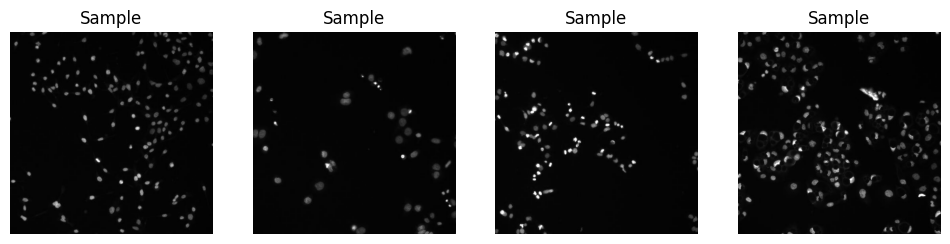

In [ ]:
import matplotlib.pyplot as plt

sample_imgs = jpg_files[:4]

plt.figure(figsize=(12,6))

for i, img_path in enumerate(sample_imgs):
    img = Image.open(img_path)
    plt.subplot(1,4,i+1)
    plt.imshow(img)
    plt.title("Sample")
    plt.axis("off")

plt.show()

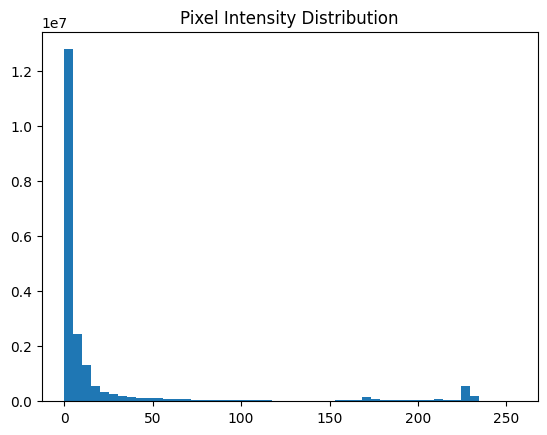

In [ ]:
all_pixels = []

for img_path in jpg_files[:100]:
    img = np.array(Image.open(img_path).convert("L"))
    all_pixels.extend(img.flatten())

plt.hist(all_pixels, bins=50)
plt.title("Pixel Intensity Distribution")
plt.show()

In [ ]:
mask_files = glob.glob("nu_data/**/*.png", recursive=True)

unique_values = set()

for m in mask_files[:100]:
    mask = np.array(Image.open(m))
    unique_values.update(np.unique(mask))

print("Unique mask values:", unique_values)

Unique mask values: {np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(4), np.uint8(5), np.uint8(6), np.uint8(7), np.uint8(8), np.uint8(9), np.uint8(10), np.uint8(11), np.uint8(12), np.uint8(13), np.uint8(14), np.uint8(15), np.uint8(16), np.uint8(17), np.uint8(18), np.uint8(19), np.uint8(20), np.uint8(21), np.uint8(22), np.uint8(23), np.uint8(24), np.uint8(25), np.uint8(26), np.uint8(27), np.uint8(28), np.uint8(29), np.uint8(30), np.uint8(31), np.uint8(32), np.uint8(33), np.uint8(34), np.uint8(35), np.uint8(36), np.uint8(37), np.uint8(38), np.uint8(39), np.uint8(40), np.uint8(41), np.uint8(42), np.uint8(43), np.uint8(44), np.uint8(45), np.uint8(46), np.uint8(47), np.uint8(48), np.uint8(49), np.uint8(50), np.uint8(51), np.uint8(52), np.uint8(53), np.uint8(54), np.uint8(55), np.uint8(56), np.uint8(57), np.uint8(58), np.uint8(59), np.uint8(60), np.uint8(61), np.uint8(62), np.uint8(63), np.uint8(64), np.uint8(65), np.uint8(66), np.uint8(67), np.uint8(68), np.uint8(69), np.uint8(

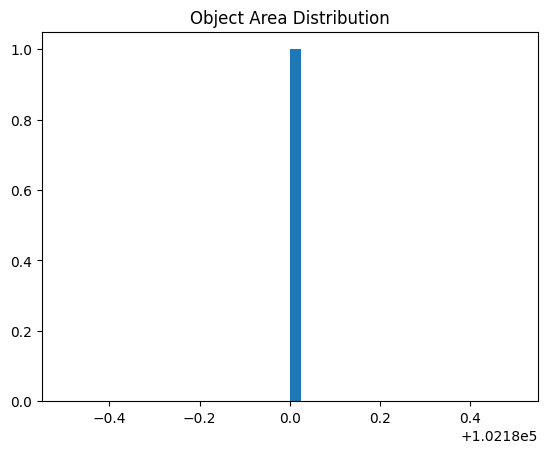

In [ ]:
import cv2

areas = []

for m in mask_files[:100]:
    mask = cv2.imread(m, 0)
    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    for c in contours:
        area = cv2.contourArea(c)
        areas.append(area)

plt.hist(areas, bins=40)
plt.title("Object Area Distribution")
plt.show()

In [ ]:
print("Train images:", len(glob.glob("nu_data/stage_1_train/*.jpg")))
print("Test images:", len(glob.glob("nu_data/stage_1_test/*.jpg")))

Train images: 664
Test images: 65
